# Blueprint: 4 Fases

## Fase I: Cimentación y Baseline
- **Análisis Exploratorio (EDA):** Identificar el desbalance de las 5 clases (Muy malo a Muy bueno).
- **Pipeline de Limpieza:** Crear una función de preprocesamiento (regex, lematización).
- **Modelo Baseline:** Implementar un TF-IDF + Random Forest (Mejores resultados en experiencia personal). El F1-Score debe ser menor a la Bi-LSTM.

## Fase II: Arquitectura Bi-LSTM 
- **Requisito principal del profe**
- **Preparación de Embeddings:** Cargar FastText (Spanish) y crear la matriz de pesos.
- **Construcción del Grafo:** Definir la Bi-LSTM con capas de SpatialDropout y GlobalMaxPooling.
- **Entrenamiento Inicial:** Validar que el modelo "aprenda" (que el Loss baje).

## Fase III: Optimización
- **Manejo de Desbalance:** Implementar Class Weights en la función de pérdida.
- **Ajuste de Hiperparámetros:** Usar Optuna para encontrar el mejor learning rate, hidden dim y dropout de forma automática.
- **Comparativa Requerida por el profe:** Documentar la diferencia entre usar TF-IDF vs. Embeddings.

## Fase IV: Preparación para la Defensa 
- **Visualización de Métricas:** Gráficas de Accuracy/Loss, Matrices de Confusión y reporte de clasificación (Precision, Recall, F1).
- **Análisis de Errores:** Identificar en qué clases falla más el modelo (ej. ¿confunde "Malo" con "Neutral"?).

# Pipeline propuesto: Clasificación de Polaridad Rest-Mex 2025

**Objetivo:** Clasificación multiclase (1-5) para el análisis de sentimiento en reseñas turísticas mexicanas, optimizando el Macro F1-Score ante un desbalance de clases del 65% en la categoría dominante.

---

## Fase I: Baseline

Se implementará una limpieza de texto que prioriza la preservación de la carga semántica. Se optó por la lematización sobre el stemming para mantener la validez lingüística de los términos, crucial en el análisis de opinión (Manning et al., 2008).

- **Baseline:** Se utilizará un modelo de Random Forest con vectores TF-IDF (1-3 n-grams).

---

## Fase II: Arquitectura Bi-LSTM y Embeddings

- **Contexto Bidireccional** 
- **Embeddings de FastText:** A diferencia de Word2Vec, FastText utiliza información de sub-palabras (n-gramas de caracteres), lo que permite al modelo manejar neologismos y errores ortográficos comunes en redes sociales y reseñas (Bojanowski et al., 2017).

---

## Fase III: Estrategias de Optimización y Desbalance

Dado el desbalance extremo reportado en las estadísticas del dataset (Clase 5: 136k vs Clase 1: 5.4k), se aplicará:

- **Weighted Cross-Entropy:** Ajuste de la función de pérdida asignando pesos inversamente proporcionales a la frecuencia de las clases, penalizando con mayor rigor los errores en clases minoritarias (King & Zeng, 2001).
- **Regularización Avanzada:** Implementación de `SpatialDropout1D` para promover la independencia de las características en la capa de embedding y evitar el sobreajuste.
- **Calibración Automática:** Uso de **Optuna** para la optimización Bayesiana de hiperparámetros (LR, Dropout, Hidden Dim), asegurando la convergencia hacia un óptimo global.

---

## Fase IV: Evaluación Multidimensional

Para asegurar que el modelo no esté sesgado hacia la clase mayoritaria, la métrica principal de optimización será el **Macro F1-Score**. Complementariamente, se analizará la **Matriz de Confusión** para evaluar errores ordinales (ej. confusiones entre clases adyacentes vs clases extremas), proporcionando una visión cualitativa del rendimiento del modelo (Sokolova & Lapalme, 2009).

---

## Referencias Bibliográficas

1. Bojanowski, P., et al. (2017). *Enriching Word Vectors with Subword Information*. TACL. *(Justifica el uso de FastText).*
2. Breiman, L. (2001). *Random Forests*. Machine Learning. *(Justifica el Baseline).*
3. Graves, A., & Schmidhuber, J. (2005). *Framewise phoneme classification with bidirectional LSTM networks*. Neural Networks. *(Justifica la Bi-LSTM).*
4. King, G., & Zeng, L. (2001). *Logistic Regression in Rare Events Data*. Political Analysis. *(Justifica el Weighted Loss).*
5. Manning, C., et al. (2008). *Introduction to Information Retrieval*. Cambridge University Press. *(Justifica TF-IDF y Preprocesamiento).*

# Justificación Técnica y Sustento Bibliográfico: Rest-Mex 2025

| **Justificación de la Técnica / Algoritmo** | **Referencia Bibliográfica** |
|---|---|
| Uso del dataset Rest-Mex y adopción del **Macro F1-Score** como métrica estándar para evaluar la robustez ante el desbalance de clases. | Álvarez-Carmona, M. A., et al. (2023). *Overview of Rest-Mex at IberLEF 2023.* |
| Implementación de **Lematización** y normalización de texto para preservar la validez lingüística y reducir la dispersión del vocabulario. | Manning, C., et al. (2008). *Introduction to Information Retrieval.* |
| Elección de **Random Forest** como modelo Baseline por su alta tolerancia al ruido y capacidad de capturar interacciones no lineales. | Breiman, L. (2001). *Random Forests.* |
| Uso de arquitectura **Bi-LSTM** para captar dependencias de largo alcance y el contexto semántico bidireccional en español. | Graves, A., & Schmidhuber, J. (2005). *Framewise phoneme classification with bidirectional LSTM.* |
| Integración de **FastText** para mitigar el problema de palabras fuera de vocabulario (OOV) mediante el uso de n-gramas de caracteres. | Bojanowski, P., et al. (2017). *Enriching Word Vectors with Subword Information.* |
| Aplicación de **Pesos de Clase (Weighted Loss)** en la función de pérdida para corregir el sesgo hacia la clase mayoritaria. | King, G., & Zeng, L. (2001). *Logistic Regression in Rare Events Data.* |
| Validación de la combinación **Bi-LSTM + FastText** como estado del arte en el dominio específico del turismo mexicano. | Ramírez-Guzmán, J., et al. (2021). *Using FastText and Bi-LSTM for Sentiment Analysis.* |
| Evaluación multidimensional mediante **Matrices de Confusión** para detectar errores ordinales en clasificaciones de 5 niveles. | Sokolova, M., & Lapalme, G. (2009). *A systematic analysis of performance measures for classification.* |

## 1. Configuración y Hardware


In [2]:
import torch
import pandas as pd
import numpy as np
import re
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU detectada: NVIDIA GeForce RTX 3090


## 2. Preprocesamiento

In [3]:
def clean_text(text):
    if not isinstance(text, str): return ""
    # Normalización de caracteres y encoding
    text = text.lower()
    text = "".join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[^a-zñ!¡?¿ ]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # Reducir repeticiones
    return text.strip()


## 3. Definición de la Bi-LSTM


In [4]:
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix=None):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        
        self.spatial_dropout = nn.Dropout(0.3) # Dropout estándar para simplificar
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, x):
        x = self.embedding(x)
        x = self.spatial_dropout(x)
        lstm_out, _ = self.lstm(x)
        pooled, _ = torch.max(lstm_out, dim=1)
        out = self.bn(pooled)
        return self.fc(out)

## 4. Próximos Pasos
1. Cargar el dataset `.csv`.
2. Generar el vocabulario y la matriz de embeddings (FastText).
3. Entrenar usando `CrossEntropyLoss(weight=class_weights)`.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import re
import unicodedata

# 1. Carga del Dataset
print("Cargando dataset...")
df = pd.read_csv(r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\Rest-Mex_2025_train.csv')

# 2. Preprocesamiento
def simple_clean(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Eliminar acentos
    text = "".join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    # Limpieza básica de caracteres
    text = re.sub(r'[^a-zñ\s]', '', text)
    return text.strip()

print("Limpiando textos (Concatenando Title + Review)...")
df['text_combined'] = (df['Title'].fillna('') + " " + df['Review'].fillna('')).apply(simple_clean)

# 3. División de datos (Estratificada por el desbalance)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df['text_combined'], 
    df['Polarity'], 
    test_size=0.20, 
    stratify=df['Polarity'], 
    random_state=42
)

Cargando dataset...
Limpiando textos (Concatenando Title + Review)...


Entrenando Random Forest (esto puede tardar unos minutos)...

--- Reporte de Clasificación (Baseline) ---
              precision    recall  f1-score   support

         1.0       0.82      0.01      0.02      1088
         2.0       1.00      0.00      0.00      1099
         3.0       1.00      0.00      0.00      3104
         4.0       0.71      0.00      0.00      9007
         5.0       0.66      1.00      0.79     27313

    accuracy                           0.66     41611
   macro avg       0.84      0.20      0.16     41611
weighted avg       0.71      0.66      0.52     41611



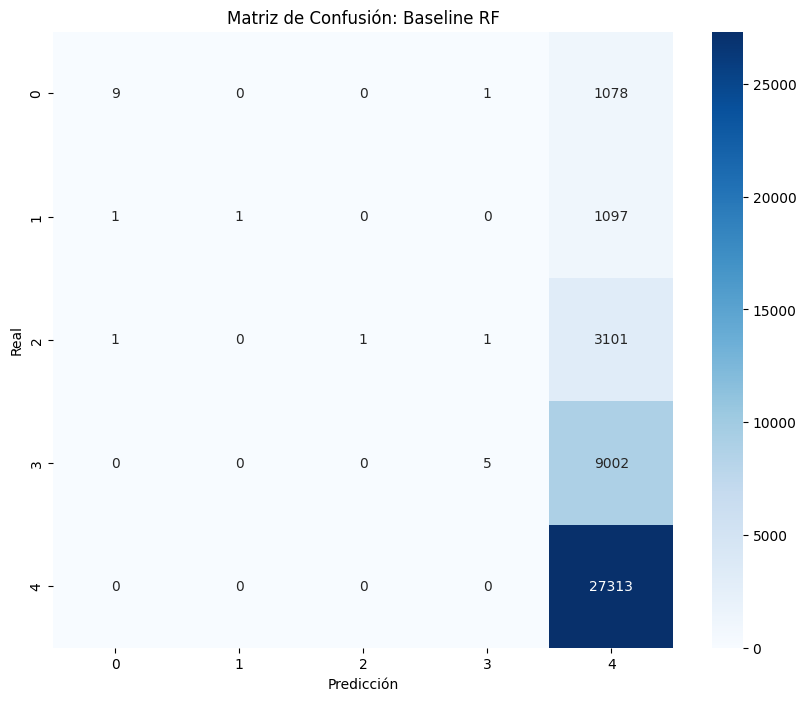

In [7]:
# 4. Vectorización TF-IDF
# Usamos max_features alto aprovechando tus 128GB de RAM
vectorizer = TfidfVectorizer(max_features=25000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_val = vectorizer.transform(X_val_raw)

# 5. Modelo Baseline: Random Forest con Pesos Balanceados
# class_weight='balanced' aplica la fórmula: w_i = N / (C * n_i)
# donde N es total de muestras, C el número de clases y n_i las muestras de la clase i.
print("Entrenando Random Forest (esto puede tardar unos minutos)...")
baseline_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20,          # Limitamos profundidad para evitar overfitting a la clase 5
    #class_weight='balanced', 
    n_jobs=-1,             # Usa todos los núcleos de tu Xeon Gold
    random_state=42
)

baseline_model.fit(X_train, y_train)

# 6. Predicciones y Métricas
y_pred = baseline_model.predict(X_val)

print("\n--- Reporte de Clasificación (Baseline) ---")
print(classification_report(y_val, y_pred))

# Matriz de Confusión para detectar sesgos
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Baseline RF')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [7]:
# 4. Vectorización TF-IDF
# Usamos max_features alto aprovechando tus 128GB de RAM
vectorizer = TfidfVectorizer(max_features=25000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_val = vectorizer.transform(X_val_raw)

# 5. Modelo Baseline: Random Forest con Pesos Balanceados
# class_weight='balanced' aplica la fórmula: w_i = N / (C * n_i)
# donde N es total de muestras, C el número de clases y n_i las muestras de la clase i.
print("Entrenando Random Forest (esto puede tardar unos minutos)...")
baseline_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20,          # Limitamos profundidad para evitar overfitting a la clase 5
    class_weight='balanced', 
    n_jobs=-1,             # Usa todos los núcleos de tu Xeon Gold
    random_state=42
)

baseline_model.fit(X_train, y_train)

Entrenando Random Forest (esto puede tardar unos minutos)...


,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



--- Reporte de Clasificación (Baseline) ---
              precision    recall  f1-score   support

         1.0       0.36      0.68      0.47      1088
         2.0       0.19      0.17      0.18      1099
         3.0       0.29      0.42      0.34      3104
         4.0       0.42      0.36      0.39      9007
         5.0       0.82      0.79      0.81     27313

    accuracy                           0.65     41611
   macro avg       0.42      0.49      0.44     41611
weighted avg       0.67      0.65      0.66     41611



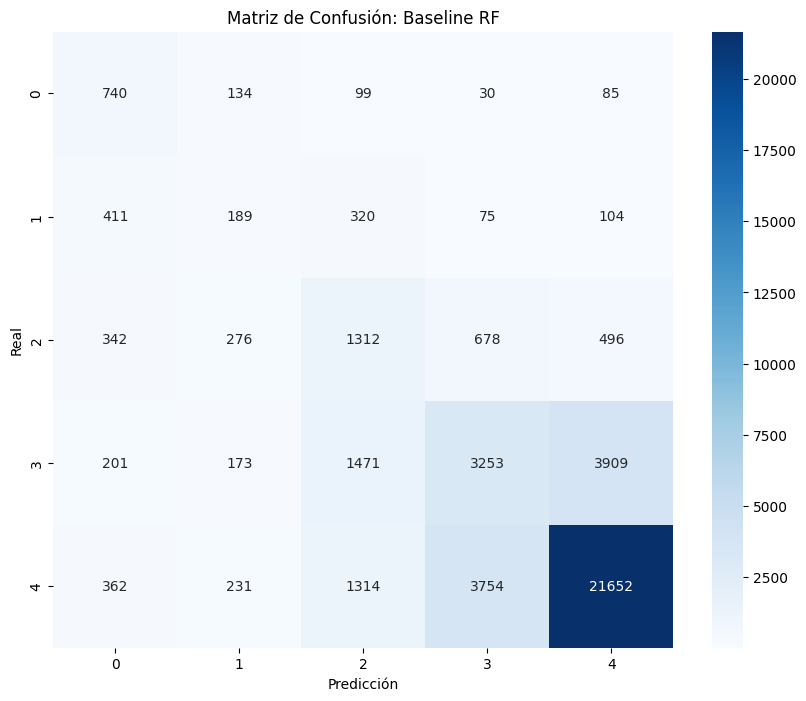

In [8]:
# 6. Predicciones y Métricas
y_pred = baseline_model.predict(X_val)

print("\n--- Reporte de Clasificación (Baseline) ---")
print(classification_report(y_val, y_pred))

# Matriz de Confusión para detectar sesgos
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Baseline RF')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [10]:
# Limpieza avanzada
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import re
import unicodedata
import spacy
import unicodedata
from langdetect import detect, DetectorFactory
from emoji import demojize
from tqdm import tqdm
tqdm.pandas()


# 1. Carga del Dataset
print("Cargando dataset...")
df = pd.read_csv(r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\Rest-Mex_2025_train.csv')

# Para que la detección de idioma sea reproducible
DetectorFactory.seed = 42

# Cargamos spaCy (lg tiene mejores vectores para lematizar)
nlp = spacy.load("es_core_news_lg", disable=['ner', 'parser'])

def advanced_clean(text):
    if not isinstance(text, str) or len(text) < 5: 
        return ""

    # 1. Detección de Idioma (Filtro inicial)
    try:
        if detect(text) != 'es':
            return ""
    except:
        return ""

    # 2. Eliminar restos de botones "Leer más"
    # El patrón r'\.\s*\.\s*\.\s*más' detecta variantes como ". . . más", "...Más", etc.
    text = re.sub(r'\.\s*\.\s*\.\s*m[aá]s', ' ', text, flags=re.IGNORECASE)

    # 3. URLs, Correos y Posesivos ingleses
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URLs
    text = re.sub(r'\S*@\S*\s?', '', text) # Emails
    text = re.sub(r"\'s|s\'", '', text) # Posesivos inglés ('s)

    # 4. Hashtags (quitar # pero dejar la palabra) y Símbolos Especiales
    text = text.replace('#', ' ')
    text = re.sub(r'[®~©|°¬]', '', text)

    # 5. Sustituir Emoticonos por palabras (en español)
    text = demojize(text, language='es') 
    text = text.replace(':', ' ') # Limpiar los delimitadores de los emojis convertidos

    # 6. Normalización UTF-8 y Slang (Diccionario básico)
    slang_dict = {
        # --- Calificativos Positivos (Aumentan la Polaridad 4-5) ---
        " chido": " bueno ", " chida": " buena ",
        " padre": " excelente ", " padrisimo": " excelente ",
        " fregon": " increible ", " fregona": " increible ",
        " supe r": " muy ", " requetebien": " muy bien ",
        " joya": " excelente ", " agusto": " comodo ",
        " de lujo": " excelente ", " rifado": " excelente ",
        " de pelos": " excelente ", " buena onda": " amable ",
        " a toda madre": " excelente ", # Frase común en reseñas informales
        
        # --- Calificativos Negativos (Bajan la Polaridad 1-2) ---
        " gacho": " malo ", " gacha": " mala ",
        " chafa": " mala calidad ", " chafisima": " muy mala calidad ",
        " carisimo": " costoso ", " un ojo de la cara": " costoso ",
        " de la patada": " muy malo ", " fuchi": " desagradable ",
        " asco": " desagradable ", " mugrero": " sucio ",
        " chinches": " insectos ", " estafa": " fraude ",
        
        # --- Jerga de Pueblos Mágicos y Comida ---
        " garnacha": " comida ", " antojito": " comida tipica ",
        " chela": " cerveza ", " cheve": " cerveza ",
        " pisto": " alcohol ", " chupe": " alcohol ",
        " mal del puerco": " sueño tras comer ",
        " tianguis": " mercado ", " puestero": " vendedor ",
        " marchante": " vendedor ", " artesania": " artesania ",
        
        # --- Términos de Transporte y Logística ---
        " combi": " transporte publico ", " micro": " transporte publico ",
        " camion": " autobus ", " pecero": " transporte publico ",
        " aventon": " transporte gratis ", " bache": " mal camino ",
        " terraceria": " camino sin pavimentar ",
        
        # --- Regionalismos Específicos (Norte/Sur) ---
        " cura": " divertido ", # Común en el Norte (Baja California/Sonora)
        " morro": " niño ", " morra": " niña ",
        " huay": " exclamacion ", # Común en Yucatán/Quintana Roo
        " bomba": " excelente ", # Contexto yucateco
        " pelada": " facil ", " pelado": " facil "
    }
    for word, replacement in slang_dict.items():
        text = text.replace(word, replacement)

    # 7. Lematización y Limpieza Final
    # Procesamos con spaCy para obtener lemas y quitar stopwords/puntuación
    doc = nlp(text.lower())
    
    # Solo nos quedamos con el lema si es una palabra alfabética y no es stopword
    clean_tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    
    return " ".join(clean_tokens)

# Aplicación masiva (128GB de RAM y Xeon Gold)
print("Iniciando limpieza avanzada... Esto tomará tiempo")

df['text_combined'] = (df['Title'].fillna('') + " " + df['Review'].fillna(''))

df['text_cleaned'] = df['text_combined'].progress_apply(advanced_clean)

# Eliminar las filas que quedaron vacías por el filtro de idioma
df = df[df['text_cleaned'] != ""].reset_index(drop=True)

df.to_parquet('rest_mex_cleaned.parquet')
#df.to_pickle('rest_mex_cleaned.pkl')

Cargando dataset...
Iniciando limpieza avanzada... Esto tomará tiempo


100%|██████████████████████████████████████████████████████████████████████████| 208051/208051 [49:04<00:00, 70.66it/s]


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

## Limpieza Version 2

In [62]:
import re
import unicodedata
import pandas as pd
from emoji import demojize
from langdetect import detect, LangDetectException, DetectorFactory
from tqdm import tqdm

tqdm.pandas()
DetectorFactory.seed = 42  # Reproducibilidad en detección de idioma

# ==============================================================================
# CONFIGURACION
# ==============================================================================
DATA_PATH   = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\Rest-Mex_2025_train.csv'
OUTPUT_PATH = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\rest_mex_cleaned_v2.pkl'

# ==============================================================================
# 1. CARGA DE DATOS
# ==============================================================================
print("Cargando dataset...")
df = pd.read_csv(DATA_PATH)
total_inicial = len(df)
print(f"Total de filas cargadas: {total_inicial:,}")

# ==============================================================================
# 2. PREPROCESAMIENTO
# ==============================================================================
slang_dict = {
    # Positivos
    " chido": " bueno ", " chida": " buena ",
    " padre": " excelente ", " padrisimo": " excelente ",
    " fregon": " increible ", " fregona": " increible ",
    " supe r": " muy ", " requetebien": " muy bien ",
    " joya": " excelente ", " agusto": " comodo ",
    " de lujo": " excelente ", " rifado": " excelente ",
    " de pelos": " excelente ", " buena onda": " amable ",
    " a toda madre": " excelente ",
    # Negativos
    " gacho": " malo ", " gacha": " mala ",
    " chafa": " mala calidad ", " chafisima": " muy mala calidad ",
    " carisimo": " costoso ", " un ojo de la cara": " costoso ",
    " de la patada": " muy malo ", " fuchi": " desagradable ",
    " asco": " desagradable ", " mugrero": " sucio ",
    " chinches": " insectos ", " estafa": " fraude ",
    # Comida y lugares
    " garnacha": " comida ", " antojito": " comida tipica ",
    " chela": " cerveza ", " cheve": " cerveza ",
    " pisto": " alcohol ", " chupe": " alcohol ",
    " tianguis": " mercado ", " puestero": " vendedor ",
    " marchante": " vendedor ",
    # Transporte
    " combi": " transporte publico ", " micro": " transporte publico ",
    " camion": " autobus ", " pecero": " transporte publico ",
    " aventon": " transporte gratis ", " bache": " mal camino ",
    " terraceria": " camino sin pavimentar ",
    # Regionalismos
    " cura": " divertido ",
    " morro": " nino ", " morra": " nina ",
    " bomba": " excelente ",
}

# Contadores para el reporte
conteo_idioma      = {}
eliminados_idioma  = 0
eliminados_vacios  = 0
errores_deteccion  = 0

def simple_clean_v2(text):
    global eliminados_idioma, eliminados_vacios, errores_deteccion

    if not isinstance(text, str) or len(text) < 5:
        eliminados_vacios += 1
        return ""

    # 1. Eliminar botones "Leer más"
    text = re.sub(r'\.\s*\.\s*\.\s*m[aá]s', ' ', text, flags=re.IGNORECASE)

    # 2. Filtro de idioma (sobre texto original, antes de limpiar)
    try:
        idioma = detect(text)
        conteo_idioma[idioma] = conteo_idioma.get(idioma, 0) + 1
        if idioma != 'es':
            eliminados_idioma += 1
            return ""
    except LangDetectException:
        errores_deteccion += 1
        return ""

    # 3. URLs, correos y posesivos ingleses
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S*@\S*\s?', '', text)
    text = re.sub(r"\'s|s\'", '', text)

    # 4. Hashtags y símbolos especiales
    text = text.replace('#', ' ')
    text = re.sub(r'[®~©|°¬]', '', text)

    # 5. Convertir emojis a palabras en español
    text = demojize(text, language='es')
    text = text.replace(':', ' ')

    # 6. Slang mexicano
    text = text.lower()
    for slang, replacement in slang_dict.items():
        text = text.replace(slang, replacement)

    # 8. Limpieza final de caracteres (conserva ñ y acentos)
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# ==============================================================================
# 3. APLICACION
# ==============================================================================
print("\nCombinando Title + Review...")
df['text_raw'] = df['Title'].fillna('') + " " + df['Review'].fillna('')

print("Aplicando simple_clean_v2 (esto puede tomar varios minutos)...")
df['text_combined'] = df['text_raw'].progress_apply(simple_clean_v2)

# Eliminar filas vacías resultantes
df_clean = df[df['text_combined'] != ""].reset_index(drop=True)
eliminados_post = total_inicial - len(df_clean) - eliminados_vacios - eliminados_idioma - errores_deteccion

# ==============================================================================
# 4. GUARDAR
# ==============================================================================
df_clean.to_pickle(OUTPUT_PATH)
print(f"\nDataset guardado en: {OUTPUT_PATH}")

# ==============================================================================
# 5. REPORTE
# ==============================================================================
total_final     = len(df_clean)
total_eliminado = total_inicial - total_final

print("\n" + "=" * 55)
print("REPORTE DE PREPROCESAMIENTO - Rest-Mex 2025")
print("=" * 55)

print(f"\nDOCUMENTOS")
print(f"  Total inicial:                  {total_inicial:>8,}")
print(f"  Total final (utiles):           {total_final:>8,}")
print(f"  Total eliminados:               {total_eliminado:>8,}  ({100*total_eliminado/total_inicial:.2f}%)")

print(f"\nCAUSAS DE ELIMINACION")
print(f"  Texto vacio o muy corto:        {eliminados_vacios:>8,}  ({100*eliminados_vacios/total_inicial:.2f}%)")
print(f"  Idioma no español:              {eliminados_idioma:>8,}  ({100*eliminados_idioma/total_inicial:.2f}%)")
print(f"  Error en deteccion de idioma:   {errores_deteccion:>8,}  ({100*errores_deteccion/total_inicial:.2f}%)")

print(f"\nIDIOMAS DETECTADOS (todos)")
idiomas_ordenados = sorted(conteo_idioma.items(), key=lambda x: x[1], reverse=True)
for idioma, cantidad in idiomas_ordenados:
    etiqueta = "(conservado)" if idioma == 'es' else "(eliminado) "
    print(f"  {idioma:<6} {etiqueta}  {cantidad:>8,}  ({100*cantidad/total_inicial:.2f}%)")

print(f"\nTEXTO COMBINADO (Title + Review)")
longitudes = df_clean['text_combined'].str.split().str.len()
print(f"  Longitud promedio (tokens):     {longitudes.mean():>8.1f}")
print(f"  Longitud mediana (tokens):      {longitudes.median():>8.1f}")
print(f"  Longitud maxima (tokens):       {longitudes.max():>8,}")
print(f"  Longitud minima (tokens):       {longitudes.min():>8,}")
print(f"  Percentil 95 (tokens):          {longitudes.quantile(0.95):>8.1f}")

print(f"\nDISTRIBUCION DE CLASES (Polarity)")
dist = df_clean['Polarity'].value_counts().sort_index()
for polarity, count in dist.items():
    barra = "#" * int(40 * count / dist.max())
    print(f"  Polarity {polarity}: {count:>7,}  ({100*count/total_final:.2f}%)  {barra}")

print("\n" + "=" * 55)


Cargando dataset...
Total de filas cargadas: 208,051

Combinando Title + Review...
Aplicando simple_clean_v2 (esto puede tomar varios minutos)...


100%|█████████████████████████████████████████████████████████████████████████| 208051/208051 [30:17<00:00, 114.50it/s]



Dataset guardado en: C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\rest_mex_cleaned_v2.pkl

REPORTE DE PREPROCESAMIENTO - Rest-Mex 2025

DOCUMENTOS
  Total inicial:                   208,051
  Total final (utiles):            207,688
  Total eliminados:                    363  (0.17%)

CAUSAS DE ELIMINACION
  Texto vacio o muy corto:               0  (0.00%)
  Idioma no español:                   363  (0.17%)
  Error en deteccion de idioma:          0  (0.00%)

IDIOMAS DETECTADOS (todos)
  es     (conservado)   207,688  (99.83%)
  en     (eliminado)        324  (0.16%)
  pt     (eliminado)         13  (0.01%)
  it     (eliminado)          8  (0.00%)
  ca     (eliminado)          7  (0.00%)
  fr     (eliminado)          5  (0.00%)
  so     (eliminado)          2  (0.00%)
  id     (eliminado)          1  (0.00%)
  no     (eliminado)          1  (0.00%)
  sq     (eliminado)          1  (0.00%)
  de     (eliminado)          1  (0.00%)

TEXTO COMBINADO (Title + Review)
  Longitud promed

Entrenando Random Forest (esto puede tardar unos minutos)...

--- Reporte de Clasificación (Baseline) ---
              precision    recall  f1-score   support

         1.0       0.35      0.70      0.46      1087
         2.0       0.22      0.22      0.22      1097
         3.0       0.33      0.29      0.31      3102
         4.0       0.36      0.45      0.40      9000
         5.0       0.83      0.74      0.78     27251

    accuracy                           0.63     41537
   macro avg       0.42      0.48      0.44     41537
weighted avg       0.66      0.63      0.64     41537



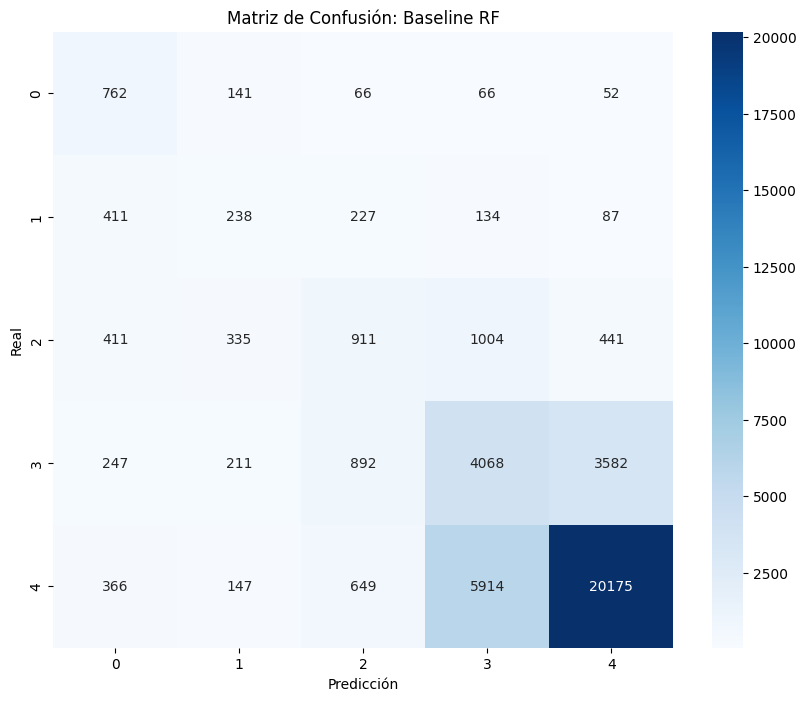

In [20]:
# 3. División de datos (Estratificada por el desbalance)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df['text_cleaned'], 
    df['Polarity'], 
    test_size=0.20, 
    stratify=df['Polarity'], 
    random_state=42
)
# 4. Vectorización TF-IDF
# Usamos max_features alto aprovechando tus 128GB de RAM
vectorizer = TfidfVectorizer(max_features=25000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_raw)
X_val = vectorizer.transform(X_val_raw)

# 5. Modelo Baseline: Random Forest con Pesos Balanceados
# class_weight='balanced' aplica la fórmula: w_i = N / (C * n_i)
# donde N es total de muestras, C el número de clases y n_i las muestras de la clase i.
print("Entrenando Random Forest (esto puede tardar unos minutos)...")
baseline_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=20,          # Limitamos profundidad para evitar overfitting a la clase 5
    class_weight='balanced', 
    n_jobs=-1,             # Usa todos los núcleos de tu Xeon Gold
    random_state=42
)

baseline_model.fit(X_train, y_train)

# 6. Predicciones y Métricas
y_pred = baseline_model.predict(X_val)

print("\n--- Reporte de Clasificación (Baseline) ---")
print(classification_report(y_val, y_pred))

# Matriz de Confusión para detectar sesgos
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Baseline RF')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## Fase II: Arquitectura Bi-LSTM y Embeddings

In [32]:
# ==============================================================================
# LIBRERIAS
# ==============================================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import fasttext
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from datetime import datetime

In [59]:
# ==============================================================================
# CONFIGURACION
# ==============================================================================

now = datetime.now() # Obtener la fecha y hora actual
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")
RUTA = r'C:\Users\AaronMCC\Documents\Rest-Mex2025'
FASTTEXT_PATH = RUTA + r'\dataset\cc.es.300.bin'
DATASET_PATH  = RUTA + r'\dataset\rest_mex_cleaned.pkl'
CSV_OUTPUT    = RUTA + r'\resultados\training_history_' + date_time + '.csv'

EPOCHS        = 20
BATCH_SIZE    = 256
HIDDEN_DIM    = 128
MAX_FEATURES  = 100_000
LEARNING_RATE = 0.002494998277098372
DROPOUT       = 0.25562306762754566
EMBED_DIM     = 300
W_DECAY       = 2.3371875941792994e-05

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")


Dispositivo: cuda


In [63]:
df_clean

,Title,Review,Polarity,Town,Region,Type,text_raw,text_combined
0,Mi Lugar Favorito!!!!,Excelente lugar para comer y pasar una buena n...,5.0,Sayulita,Nayarit,Restaurant,Mi Lugar Favorito!!!! Excelente lugar para com...,mi lugar favorito excelente lugar para comer y...
1,lugares interesantes para visitar,"andar mucho, así que un poco difícil para pers...",4.0,Tulum,QuintanaRoo,Attractive,"lugares interesantes para visitar andar mucho,...",lugares interesantes para visitar andar mucho ...
2,No es el mismo Dreams,"Es nuestra cuarta visita a Dreams Tulum, elegi...",3.0,Tulum,QuintanaRoo,Hotel,No es el mismo Dreams Es nuestra cuarta visit...,no es el mismo dreams es nuestra cuarta visita...
3,un buen panorama cerca de CancÃºn,"Estando en CancÃºn, fuimos al puerto y tomamos...",4.0,Isla_Mujeres,QuintanaRoo,Attractive,un buen panorama cerca de CancÃºn Estando en C...,un buen panorama cerca de cancn estando en can...
4,El mejor,Es un lugar antiguo y por eso me encanto tiene...,5.0,Patzcuaro,Michoacan,Hotel,El mejor Es un lugar antiguo y por eso me enca...,el mejor es un lugar antiguo y por eso me enca...
...,...,...,...,...,...,...,...,...
207683,"excelente ambiente, comida y atencion","Excelente Restaurante, comida Mexicana de alto...",5.0,Tequisquiapan,Queretaro,Restaurant,"excelente ambiente, comida y atencion Excelent...",excelente ambiente comida y atencion excelente...
207684,Muy mal servicio,Estuvimos allí como huéspedes de un día a la p...,2.0,Tulum,QuintanaRoo,Hotel,Muy mal servicio Estuvimos allí como huéspedes...,muy mal servicio estuvimos allí como huéspedes...
207685,Excelente,"Excelente comida, así como la atención y servi...",5.0,Ixtapan_de_la_Sal,Estado_de_Mexico,Restaurant,"Excelente Excelente comida, así como la atenci...",excelente excelente comida así como la atenció...
207686,Visita nocturna,Nos toco visitar este sitio cuando ya había ca...,4.0,Creel,Chihuahua,Attractive,Visita nocturna Nos toco visitar este sitio cu...,visita nocturna nos toco visitar este sitio cu...


Cargando modelo FastText...
Vocabulario: 100,002 tokens
Longitud maxima de secuencia (p95): 146
Train: 176,534 | Val: 31,154

Iniciando entrenamiento (20 epocas)...
Epoca |  T-Loss |   T-Acc |  V-Loss |   V-Acc |    V-F1 |      LR
------------------------------------------------------------------------
    1 |   1.144 |  57.04% |   0.960 |  64.23% |  51.11% | LR: 2.49e-03
    2 |   0.968 |  64.60% |   0.944 |  59.97% |  50.81% | LR: 2.49e-03
    3 |   0.935 |  65.62% |   0.918 |  64.00% |  54.29% | LR: 2.49e-03
    4 |   0.913 |  66.34% |   0.905 |  70.25% |  56.84% | LR: 2.49e-03
    5 |   0.906 |  66.67% |   0.904 |  68.18% |  53.39% | LR: 2.49e-03
    6 |   0.888 |  66.95% |   0.892 |  67.22% |  55.29% | LR: 2.49e-03
    7 |   0.882 |  67.15% |   0.886 |  66.97% |  55.33% | LR: 2.49e-03
    8 |   0.854 |  67.85% |   0.880 |  69.19% |  56.69% | LR: 1.25e-03
    9 |   0.844 |  68.11% |   0.887 |  70.00% |  57.39% | LR: 1.25e-03
   10 |   0.838 |  68.16% |   0.892 |  70.66% |  57.13% |

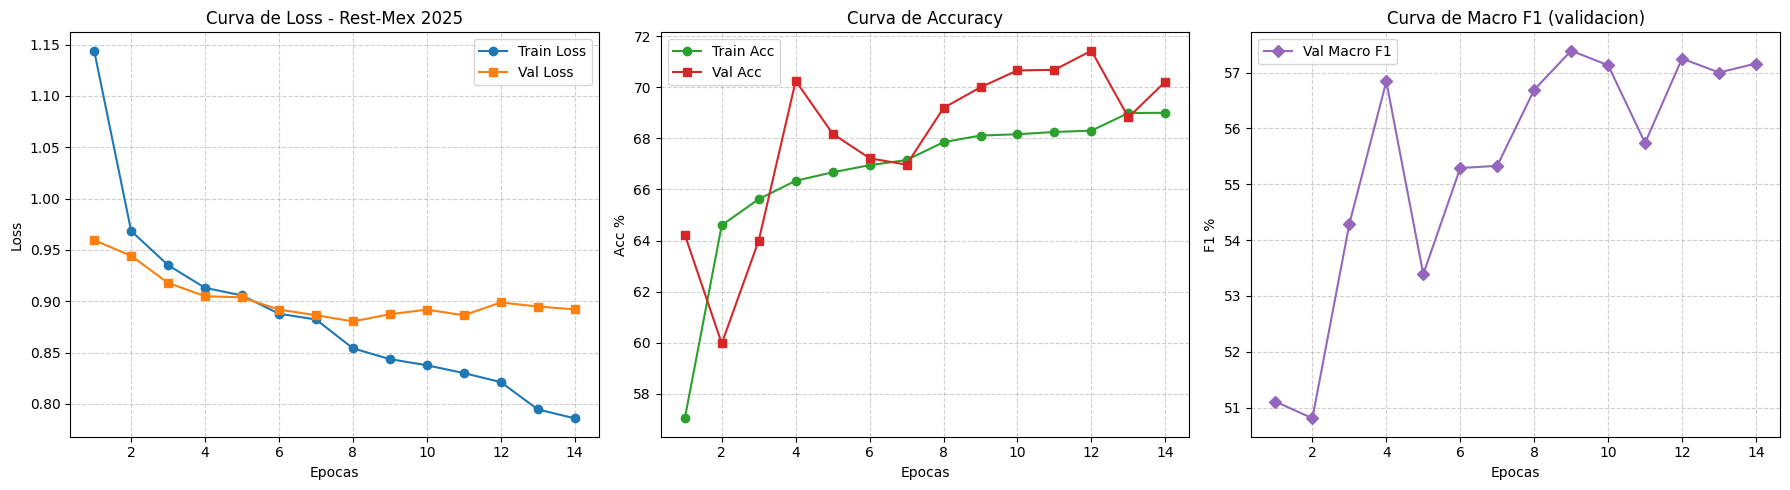

Grafica guardada en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\curvas_entrenamiento_13_03_2026_21_21_10.png
Mejor epoca: 9 | Mejor V-F1: 57.39%
              precision    recall  f1-score   support

Muy negativo       0.60      0.74      0.66       815
    Negativo       0.36      0.45      0.40       823
     Neutral       0.45      0.52      0.48      2326
    Positivo       0.45      0.57      0.50      6751
Muy positivo       0.89      0.77      0.83     20439

    accuracy                           0.70     31154
   macro avg       0.55      0.61      0.57     31154
weighted avg       0.74      0.70      0.71     31154



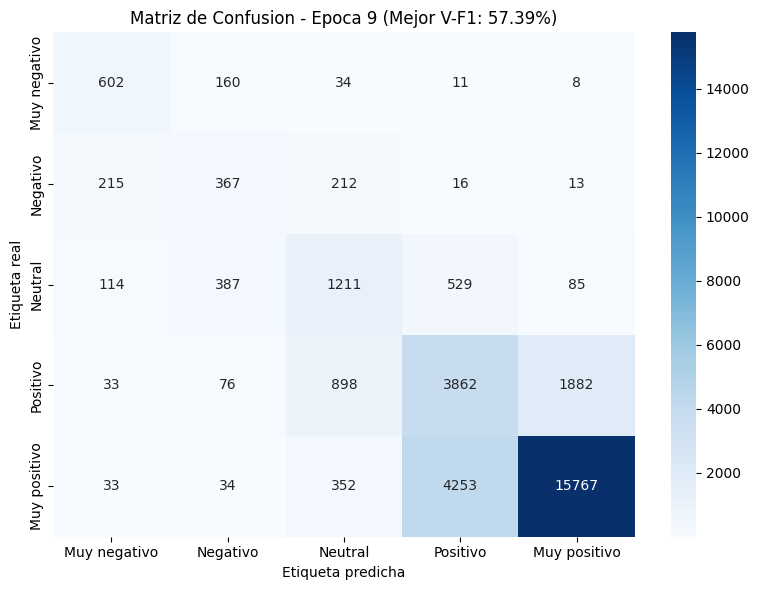

In [65]:

# ==============================================================================
# 1. CARGA DE DATOS
# ==============================================================================
#df = pd.read_pickle(DATASET_PATH)
df = df_clean
df['label'] = df['Polarity'].astype(int) - 1  # Rango 0-4

# ==============================================================================
# 2. EMBEDDINGS FASTTEXT
# ==============================================================================
print("Cargando modelo FastText...")
ft = fasttext.load_model(FASTTEXT_PATH)

def build_vocab_and_matrix(texts, ft_model, max_features=MAX_FEATURES):
    counts = Counter()
    for text in texts:
        counts.update(text.split())

    vocab = {word: i + 2 for i, (word, _) in enumerate(counts.most_common(max_features))}
    vocab['<PAD>'] = 0
    vocab['<OOV>'] = 1

    embedding_matrix = np.zeros((len(vocab), EMBED_DIM))
    for word, i in vocab.items():
        if i > 1:
            embedding_matrix[i] = ft_model.get_word_vector(word)
        elif i == 1:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

    return vocab, torch.tensor(embedding_matrix, dtype=torch.float32)

vocab, embedding_matrix = build_vocab_and_matrix(df['text_combined'], ft)
del ft
print(f"Vocabulario: {len(vocab):,} tokens")

# ==============================================================================
# 3. TOKENIZACION Y DATASET
# ==============================================================================
MAX_LEN = int(df['text_combined'].str.split().str.len().quantile(0.95))
print(f"Longitud maxima de secuencia (p95): {MAX_LEN}")

def tokenize_text(text, vocab, max_len):
    tokens = [vocab.get(w, 1) for w in text.split()[:max_len]]
    return tokens + [0] * (max_len - len(tokens))

class RestMexDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.sequences = [tokenize_text(t, vocab, max_len) for t in texts]
        self.labels = labels.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_df, val_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)
train_ds = RestMexDataset(train_df['text_combined'], train_df['label'], vocab, MAX_LEN)
val_ds   = RestMexDataset(val_df['text_combined'],   val_df['label'],   vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")

# ==============================================================================
# 4. ARQUITECTURA Bi-LSTM
# ==============================================================================
class SpatialDropout(nn.Dropout2d):
    def forward(self, x):
        x = x.unsqueeze(2)
        x = x.permute(0, 3, 2, 1)
        x = super().forward(x)
        x = x.permute(0, 3, 2, 1)
        x = x.squeeze(2)
        return x

class BiLSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.embedding      = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.spatial_dropout = SpatialDropout(DROPOUT)
        # Una sola capa
        #self.lstm           = nn.LSTM(EMBED_DIM, hidden_dim, bidirectional=True, batch_first=True)
        # Dos capas
        self.lstm           = nn.LSTM(EMBED_DIM, hidden_dim, num_layers=2, dropout=DROPOUT, bidirectional=True, batch_first=True)
        self.fc             = nn.Linear(hidden_dim * 2 * 2, 5)

    def forward(self, x):
        x = self.embedding(x)
        x = self.spatial_dropout(x)
        lstm_out, _ = self.lstm(x)
        avg_pool = torch.mean(lstm_out, 1)
        max_pool, _ = torch.max(lstm_out, 1)
        combined = torch.cat((avg_pool, max_pool), 1)
        return self.fc(combined)

# ==============================================================================
# 5. CONFIGURACION DE ENTRENAMIENTO
# ==============================================================================
weights      = compute_class_weight('balanced', classes=np.unique(df['label']), y=df['label'])
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

model     = BiLSTMClassifier(embedding_matrix).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=W_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# ==============================================================================
# 6. FUNCIONES DE ENTRENAMIENTO Y EVALUACION
# ==============================================================================
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    return total_loss / len(loader), 100 * correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    avg_f1   = f1_score(all_labels, all_preds, average='macro') * 100
    return avg_loss, accuracy, avg_f1, all_preds, all_labels

# ==============================================================================
# 7. LOOP DE ENTRENAMIENTO
# ==============================================================================
history = {
    'epoch': [],
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],  'val_f1': []
}

print(f"\nIniciando entrenamiento ({EPOCHS} epocas)...")
print(f"{'Epoca':>5} | {'T-Loss':>7} | {'T-Acc':>7} | {'V-Loss':>7} | {'V-Acc':>7} | {'V-F1':>7} | {'LR':>7}")
print("-" * 72)

# --- EARLY STOPPING ---
best_val_f1 = 0.0
patience = 5        # epocas sin mejora antes de detener
no_improve = 0      # contador

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc          = train_epoch(model, train_loader)
    # v_loss, v_acc, v_f1    = evaluate(model, val_loader)
    v_loss, v_acc, v_f1, all_preds, all_labels = evaluate(model, val_loader)

    history['epoch'].append(epoch)
    history['train_loss'].append(round(t_loss, 4))
    history['train_acc'].append(round(t_acc, 2))
    history['val_loss'].append(round(v_loss, 4))
    history['val_acc'].append(round(v_acc, 2))
    history['val_f1'].append(round(v_f1, 2))

    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"{epoch:>5} | {t_loss:>7.3f} | {t_acc:>6.2f}% | {v_loss:>7.3f} | {v_acc:>6.2f}% | {v_f1:>6.2f}% | LR: {current_lr:.2e}")

    scheduler.step(v_f1)
    
    
    # --- EARLY STOPPING ---
    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
    
        best_epoch     = epoch
        best_preds     = all_preds
        best_labels    = all_labels
    
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping en epoca {epoch} | Mejor V-F1: {best_val_f1:.2f}%")
            break
    
# ==============================================================================
# 8. GUARDAR HISTORIAL EN CSV
# ==============================================================================
history_df = pd.DataFrame(history)
history_df.to_csv(CSV_OUTPUT, index=False)
print(f"\nHistorial guardado en: {CSV_OUTPUT}")

# ==============================================================================
# 9. GRAFICAS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', color='#1f77b4', marker='o')
axes[0].plot(history['epoch'], history['val_loss'],   label='Val Loss',   color='#ff7f0e', marker='s')
axes[0].set_title('Curva de Loss - Rest-Mex 2025')
axes[0].set_xlabel('Epocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history['epoch'], history['train_acc'], label='Train Acc', color='#2ca02c', marker='o')
axes[1].plot(history['epoch'], history['val_acc'],   label='Val Acc',   color='#d62728', marker='s')
axes[1].set_title('Curva de Accuracy')
axes[1].set_xlabel('Epocas')
axes[1].set_ylabel('Acc %')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(history['epoch'], history['val_f1'], label='Val Macro F1', color='#9467bd', marker='D')
axes[2].set_title('Curva de Macro F1 (validacion)')
axes[2].set_xlabel('Epocas')
axes[2].set_ylabel('F1 %')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

now = datetime.now() # Obtener la fecha y hora actual
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

plt.savefig(RUTA + r'\resultados\curvas_entrenamiento_' + date_time + '.png', dpi=150)
plt.show()
print("Grafica guardada en: " + RUTA + r'\resultados\curvas_entrenamiento_' + date_time + '.png')

def evaluate_full(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

# Reporte de clasificacion
print(f"Mejor epoca: {best_epoch} | Mejor V-F1: {best_val_f1:.2f}%")
print(classification_report(best_labels, best_preds, target_names=class_names))

# Matriz de confusion
cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Matriz de Confusion - Epoca {best_epoch} (Mejor V-F1: {best_val_f1:.2f}%)')
plt.ylabel('Etiqueta real')
plt.xlabel('Etiqueta predicha')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Fase III: Optuna

Dispositivo: cuda
Cargando modelo FastText...
Vocabulario: 100,002 tokens
Longitud maxima de secuencia (p95): 146
Train: 176,534 | Val: 31,154

Iniciando busqueda de hiperparametros (30 trials)...


Best trial: 18. Best value: 57.5039: 100%|████████████████████████████████| 30/30 [1:25:52<00:00, 171.77s/it]



Mejor V-F1:         57.50%
Mejores hiperparametros:
  hidden_dim: 128
  num_layers: 1
  dropout: 0.32081334888547125
  lr: 0.009557433109576362
  weight_decay: 1.0863530879445733e-05
  freeze: True

Resultados Optuna guardados en: optuna_results.csv

Entrenamiento final con mejores hiperparametros (20 epocas)...
Epoca |  T-Loss |   T-Acc |  V-Loss |   V-Acc |    V-F1 |         LR
---------------------------------------------------------------------------
    1 |   1.085 |  59.67% |   0.944 |  65.67% |  51.00% | LR: 9.56e-03
    2 |   0.953 |  65.42% |   0.948 |  68.38% |  51.75% | LR: 9.56e-03
    3 |   0.924 |  66.15% |   0.923 |  60.49% |  51.48% | LR: 9.56e-03
    4 |   0.914 |  66.54% |   0.906 |  67.86% |  54.31% | LR: 9.56e-03
    5 |   0.901 |  66.95% |   0.911 |  69.85% |  55.40% | LR: 9.56e-03
    6 |   0.896 |  66.98% |   0.918 |  67.73% |  52.29% | LR: 9.56e-03
    7 |   0.886 |  67.20% |   0.906 |  65.42% |  54.90% | LR: 9.56e-03
    8 |   0.882 |  67.25% |   0.919 |  70.5

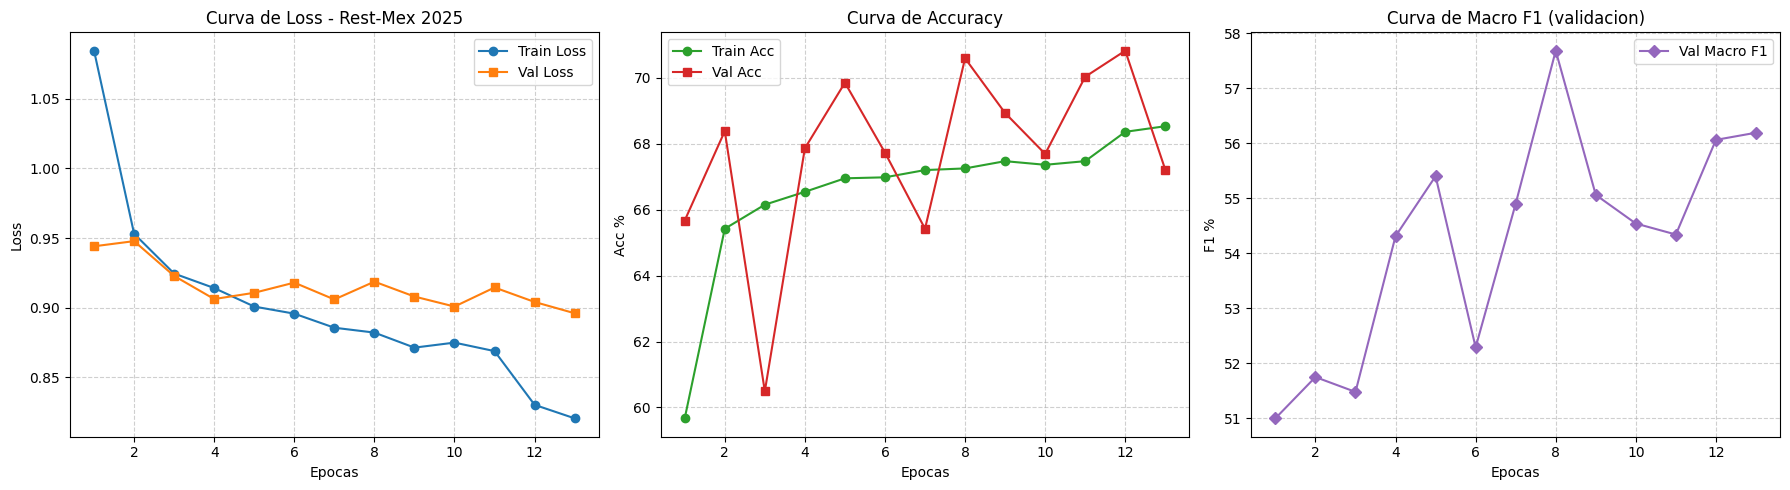

Grafica guardada en: curvas_entrenamiento.png
Mejor epoca: 8 | Mejor V-F1: 57.68%
              precision    recall  f1-score   support

Muy negativo       0.66      0.64      0.65       815
    Negativo       0.37      0.42      0.39       823
     Neutral       0.47      0.54      0.50      2326
    Positivo       0.45      0.58      0.51      6751
Muy positivo       0.89      0.78      0.83     20439

    accuracy                           0.71     31154
   macro avg       0.57      0.59      0.58     31154
weighted avg       0.74      0.71      0.72     31154



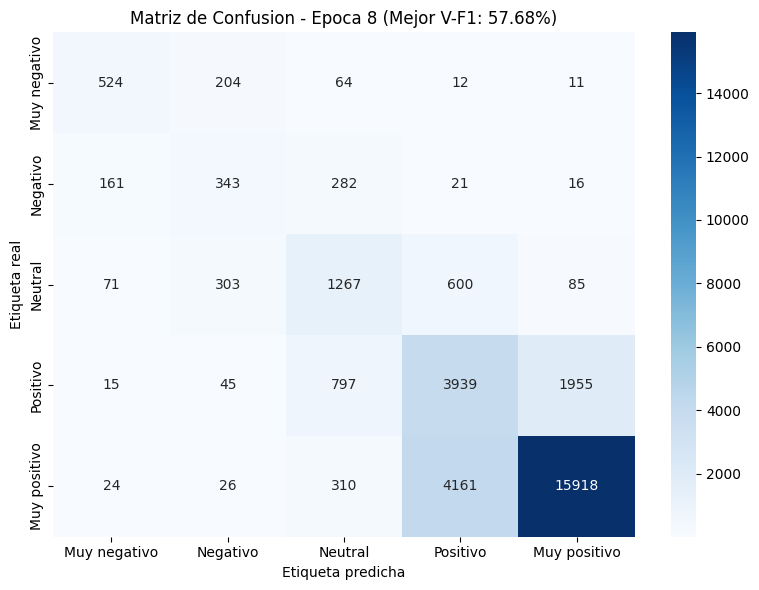

In [68]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import fasttext
import optuna
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader

# ==============================================================================
# CONFIGURACION GENERAL
# ==============================================================================
FASTTEXT_PATH = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\cc.es.300.bin'
DATA_PATH     = 'rest_mex_cleaned.pkl'
CSV_OUTPUT    = 'optuna_training_history.csv'
OPTUNA_CSV    = 'optuna_results.csv'

EPOCHS        = 10       # Epocas por trial de Optuna
N_TRIALS      = 30       # Numero de trials de Optuna
BATCH_SIZE    = 256
MAX_FEATURES  = 100_000
EMBED_DIM     = 300

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# ==============================================================================
# 1. CARGA DE DATOS
# ==============================================================================
#df = pd.read_pickle(DATA_PATH)
df = df_clean
df['label'] = df['Polarity'].astype(int) - 1  # Rango 0-4

# ==============================================================================
# 2. EMBEDDINGS FASTTEXT
# ==============================================================================
print("Cargando modelo FastText...")
ft = fasttext.load_model(FASTTEXT_PATH)

def build_vocab_and_matrix(texts, ft_model, max_features=MAX_FEATURES):
    counts = Counter()
    for text in texts:
        counts.update(text.split())

    vocab = {word: i + 2 for i, (word, _) in enumerate(counts.most_common(max_features))}
    vocab['<PAD>'] = 0
    vocab['<OOV>'] = 1

    embedding_matrix = np.zeros((len(vocab), EMBED_DIM))
    for word, i in vocab.items():
        if i > 1:
            embedding_matrix[i] = ft_model.get_word_vector(word)
        elif i == 1:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

    return vocab, torch.tensor(embedding_matrix, dtype=torch.float32)

vocab, embedding_matrix = build_vocab_and_matrix(df['text_combined'], ft)
del ft
print(f"Vocabulario: {len(vocab):,} tokens")

# ==============================================================================
# 3. TOKENIZACION Y DATASET
# ==============================================================================
MAX_LEN = int(df['text_combined'].str.split().str.len().quantile(0.95))
print(f"Longitud maxima de secuencia (p95): {MAX_LEN}")

def tokenize_text(text, vocab, max_len):
    tokens = [vocab.get(w, 1) for w in text.split()[:max_len]]
    return tokens + [0] * (max_len - len(tokens))

class RestMexDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.sequences = [tokenize_text(t, vocab, max_len) for t in texts]
        self.labels = labels.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_df, val_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=42)
train_ds = RestMexDataset(train_df['text_combined'], train_df['label'], vocab, MAX_LEN)
val_ds   = RestMexDataset(val_df['text_combined'],   val_df['label'],   vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")

# Class weights (fijos, no cambian entre trials)
weights       = compute_class_weight('balanced', classes=np.unique(df['label']), y=df['label'])
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

# ==============================================================================
# 4. ARQUITECTURA Bi-LSTM (parametrizada para Optuna)
# ==============================================================================
class SpatialDropout(nn.Dropout2d):
    def forward(self, x):
        x = x.unsqueeze(2)
        x = x.permute(0, 3, 2, 1)
        x = super().forward(x)
        x = x.permute(0, 3, 2, 1)
        x = x.squeeze(2)
        return x

class BiLSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_layers, dropout, freeze):
        super().__init__()
        self.embedding       = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze)
        self.spatial_dropout = SpatialDropout(dropout)
        self.lstm            = nn.LSTM(
            EMBED_DIM, hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim * 2 * 2, 5)

    def forward(self, x):
        x = self.embedding(x)
        x = self.spatial_dropout(x)
        lstm_out, _ = self.lstm(x)
        avg_pool = torch.mean(lstm_out, 1)
        max_pool, _ = torch.max(lstm_out, 1)
        combined = torch.cat((avg_pool, max_pool), 1)
        return self.fc(combined)

# ==============================================================================
# 5. FUNCIONES DE ENTRENAMIENTO Y EVALUACION
# ==============================================================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    return total_loss / len(loader), 100 * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    avg_f1   = f1_score(all_labels, all_preds, average='macro') * 100
    return avg_loss, accuracy, avg_f1, all_preds, all_labels

# ==============================================================================
# 6. FUNCION OBJETIVO DE OPTUNA
# ==============================================================================
def objective(trial):
    # Hiperparametros que Optuna explora
    hidden_dim   = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    num_layers   = trial.suggest_int('num_layers', 1, 2)
    dropout      = trial.suggest_float('dropout', 0.2, 0.6)
    lr           = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    freeze       = trial.suggest_categorical('freeze', [True, False])

    # Instanciar modelo, optimizer, scheduler y criterion frescos por trial
    model     = BiLSTMClassifier(embedding_matrix, hidden_dim, num_layers, dropout, freeze).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    best_f1    = 0.0
    no_improve = 0
    patience   = 3

    for epoch in range(1, EPOCHS + 1):
        train_epoch(model, train_loader, optimizer, criterion)
        _, _, v_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(v_f1)

        if v_f1 > best_f1:
            best_f1    = v_f1
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_f1

# ==============================================================================
# 7. EJECUTAR OPTUNA
# ==============================================================================
print(f"\nIniciando busqueda de hiperparametros ({N_TRIALS} trials)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Silenciar logs internos

study = optuna.create_study(direction='maximize')

study.enqueue_trial({
    'hidden_dim': 128,
    'num_layers': 2,
    'dropout': 0.25562306762754566,
    'lr': 0.002494998277098372,
    'weight_decay': 2.3371875941792994e-05,
    'freeze': True
})

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nMejor V-F1:         {study.best_value:.2f}%")
print(f"Mejores hiperparametros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Guardar resultados de todos los trials
optuna_df = study.trials_dataframe()
optuna_df.to_csv(OPTUNA_CSV, index=False)
print(f"\nResultados Optuna guardados en: {OPTUNA_CSV}")

# ==============================================================================
# 8. ENTRENAMIENTO FINAL CON LOS MEJORES HIPERPARAMETROS
# ==============================================================================
best = study.best_params
EPOCHS_FINAL = 20

print(f"\nEntrenamiento final con mejores hiperparametros ({EPOCHS_FINAL} epocas)...")

model_final     = BiLSTMClassifier(
    embedding_matrix,
    hidden_dim  = best['hidden_dim'],
    num_layers  = best['num_layers'],
    dropout     = best['dropout'],
    freeze      = best['freeze']
).to(device)

criterion_final = nn.CrossEntropyLoss(weight=class_weights)
optimizer_final = optim.Adam(model_final.parameters(), lr=best['lr'], weight_decay=best['weight_decay'])
scheduler_final = optim.lr_scheduler.ReduceLROnPlateau(optimizer_final, mode='max', factor=0.5, patience=2)

history = {
    'epoch': [],
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],  'val_f1': []
}

best_val_f1 = 0.0
no_improve  = 0
patience    = 5

print(f"{'Epoca':>5} | {'T-Loss':>7} | {'T-Acc':>7} | {'V-Loss':>7} | {'V-Acc':>7} | {'V-F1':>7} | {'LR':>10}")
print("-" * 75)

for epoch in range(1, EPOCHS_FINAL + 1):
    t_loss, t_acc       = train_epoch(model_final, train_loader, optimizer_final, criterion_final)
    v_loss, v_acc, v_f1, all_preds, all_labels = evaluate(model_final, val_loader, criterion_final)

    history['epoch'].append(epoch)
    history['train_loss'].append(round(t_loss, 4))
    history['train_acc'].append(round(t_acc, 2))
    history['val_loss'].append(round(v_loss, 4))
    history['val_acc'].append(round(v_acc, 2))
    history['val_f1'].append(round(v_f1, 2))

    scheduler_final.step(v_f1)
    current_lr = optimizer_final.param_groups[0]['lr']

    print(f"{epoch:>5} | {t_loss:>7.3f} | {t_acc:>6.2f}% | {v_loss:>7.3f} | {v_acc:>6.2f}% | {v_f1:>6.2f}% | LR: {current_lr:.2e}")

    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
    
        best_epoch     = epoch
        best_preds     = all_preds
        best_labels    = all_labels
    
        no_improve  = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping en epoca {epoch} | Mejor V-F1: {best_val_f1:.2f}%")
            break

# ==============================================================================
# 9. GUARDAR HISTORIAL EN CSV
# ==============================================================================
history_df = pd.DataFrame(history)
history_df.to_csv(CSV_OUTPUT, index=False)
print(f"\nHistorial guardado en: {CSV_OUTPUT}")

# ==============================================================================
# 10. GRAFICAS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', color='#1f77b4', marker='o')
axes[0].plot(history['epoch'], history['val_loss'],   label='Val Loss',   color='#ff7f0e', marker='s')
axes[0].set_title('Curva de Loss - Rest-Mex 2025')
axes[0].set_xlabel('Epocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history['epoch'], history['train_acc'], label='Train Acc', color='#2ca02c', marker='o')
axes[1].plot(history['epoch'], history['val_acc'],   label='Val Acc',   color='#d62728', marker='s')
axes[1].set_title('Curva de Accuracy')
axes[1].set_xlabel('Epocas')
axes[1].set_ylabel('Acc %')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(history['epoch'], history['val_f1'], label='Val Macro F1', color='#9467bd', marker='D')
axes[2].set_title('Curva de Macro F1 (validacion)')
axes[2].set_xlabel('Epocas')
axes[2].set_ylabel('F1 %')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('optuna_curvas_entrenamiento.png', dpi=150)
plt.show()
print("Grafica guardada en: curvas_entrenamiento.png")

# Matriz de confusión

class_names = ['Muy negativo', 'Negativo', 'Neutral', 'Positivo', 'Muy positivo']

print(f"Mejor epoca: {best_epoch} | Mejor V-F1: {best_val_f1:.2f}%")
print(classification_report(best_labels, best_preds, target_names=class_names))

cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusion - Epoca {best_epoch} (Mejor V-F1: {best_val_f1:.2f}%)')
plt.ylabel('Etiqueta real')
plt.xlabel('Etiqueta predicha')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()